In [1]:
"""
Framework para entrenamiento de modelos de deep learning en clasificación de imágenes médicas.
Este código se enfoca en la clasificación de osteoartritis de rodilla usando diferentes arquitecturas
de CNNs y Transformers.

Autor: [Tu nombre]
Fecha: 2025
"""

# ============================================================================
# IMPORTS
# ============================================================================

# Librerías estándar
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Métricas y validación
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    mean_absolute_error
)
from sklearn.model_selection import train_test_split

# TensorFlow y Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0, ResNet152
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization, Conv2D, Dense, Dropout, Flatten, 
    GlobalAveragePooling2D, Lambda, MaxPooling2D, Permute, 
    Rescaling, LayerNormalization
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# Transformers de Hugging Face
from transformers import (
    TFDeiTModel, TFSwinModel, TFViTModel, BeitConfig, 
    DeiTConfig, SwinConfig, ViTConfig
)

# ============================================================================
# CONFIGURACIÓN GLOBAL
# ============================================================================

# Configuración de TensorFlow para reducir logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# Rutas de datos (configuradas para Kaggle)
TRAIN_DIR = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/train'
VAL_DIR = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/val'
TEST_DIR = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/test'
CAT_DIR = '/kaggle/input/cat-knee/clean'

# Parámetros por defecto
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
SEED = 66

print("- Configuración inicial completada\n\n")
# ============================================================================
# FUNCIONES AUXILIARES
# ============================================================================
print("- Funciones auxiliares...")
def create_dataframe_from_directory(base_dir, regression=False):
    """
    Crea un DataFrame con las rutas de imágenes y sus etiquetas.
    
    Args:
        base_dir: Directorio base con subdirectorios por clase
        regression: Si True, las etiquetas son float, sino string
    
    Returns:
        DataFrame con columnas 'filename' y 'label'
    """
    data = []
    for label_str in sorted(os.listdir(base_dir)):
        label_path = os.path.join(base_dir, label_str)
        if not os.path.isdir(label_path):
            continue
            
        # Convierte etiqueta según el tipo de problema
        label = float(label_str) if regression else label_str
        
        # Añade todas las imágenes de esta clase
        for fname in os.listdir(label_path):
            data.append({
                'filename': os.path.join(label_str, fname),
                'label': label
            })
    
    return pd.DataFrame(data)


def get_num_classes(tarea, regression=False):
    """
    Determina el número de clases según la tarea.
    
    Args:
        tarea: Número de tarea (0-5)
        regression: Si es regresión
    
    Returns:
        Número de clases
    """
    if regression:
        return 1
    elif tarea == 1:
        return 3  # Clases 0-2 vs 3 vs 4
    elif tarea > 1:
        return 2  # Binaria: clase 0 vs clase objetivo
    else:
        return 5  # Multiclase: todas las clases KL (0-4)


def apply_task_transform(df, tarea):
    """
    Aplica transformaciones de etiquetas según la tarea.
    
    Args:
        df: DataFrame con columna 'label'
        tarea: Número de tarea (0-5)
    
    Returns:
        DataFrame con etiquetas transformadas
    """
    df_proc = df.copy()
    df_proc['label'] = df_proc['label'].astype(int)
    
    if tarea == 0:
        # Multiclase: mantener todas las clases KL (0-4)
        pass
    elif tarea == 1:
        # Tres clases: [0,1,2] vs [3] vs [4]
        df_proc['label'] = df_proc['label'].apply(
            lambda x: 0 if x in [0,1,2] else 1 if x == 3 else 2
        )
    elif tarea in [2,3,4,5]:
        # Binaria: clase 0 vs clase objetivo
        target = tarea - 1
        df_proc = df_proc[df_proc['label'].isin([0, target])]
        df_proc['label'] = df_proc['label'].apply(
            lambda x: 1 if x == target else 0
        )
    else:
        raise ValueError(f"Tarea {tarea} no soportada. Usar 0-5.")
    
    return df_proc.reset_index(drop=True)


def balance_dataset(df, seed=SEED):
    """
    Balancea el dataset mediante oversampling.
    
    Args:
        df: DataFrame con columna 'label'
        seed: Semilla aleatoria
    
    Returns:
        DataFrame balanceado
    """
    counts = df['label'].value_counts()
    max_count = counts.max()
    
    frames = []
    for cls, cnt in counts.items():
        df_cls = df[df['label'] == cls]
        if cnt < max_count:
            # Sobremuestreo con reemplazo
            df_cls = df_cls.sample(max_count, replace=True, random_state=seed)
        frames.append(df_cls)
    
    return pd.concat(frames).reset_index(drop=True)


# ============================================================================
# CALLBACKS Y EVALUACIÓN
# ============================================================================
print("- Callbacks y evaluación...")
class CatValidationCallback(tf.keras.callbacks.Callback):
    """
    Callback personalizado para validación en dataset de gatos.
    Evalúa el modelo en cada época y guarda el mejor.
    """
    
    def __init__(self, cat_generator, regression=False, filepath='best_model_cat.keras'):
        super().__init__()
        self.cat_generator = cat_generator
        self.regression = regression
        self.filepath = filepath
        self.epoch_metrics = []
        self.best_score = 0.0
        self.best_loss = np.inf

    def on_epoch_end(self, epoch, logs=None):
        """Evalúa el modelo al final de cada época."""
        preds = self.model.predict(self.cat_generator, verbose=0)

        if self.regression:
            # Para regresión: calcular MAE y accuracy sobre clases redondeadas
            y_pred = preds.flatten()
            y_true = self.cat_generator.labels
            loss = mean_absolute_error(y_true, y_pred)
            
            # Convertir a clases para calcular accuracy
            y_pred_class = np.clip(np.round(y_pred), 0, 4).astype(int)
            y_true_class = np.clip(np.round(y_true), 0, 4).astype(int)
            acc = accuracy_score(y_true_class, y_pred_class)
            score = acc
        else:
            # Para clasificación: evaluar loss y accuracy
            loss, acc = self.model.evaluate(self.cat_generator, verbose=0)
            score = acc

        # Guardar métricas
        self.epoch_metrics.append({
            'epoch': epoch + 1,
            'val_cat_loss': loss,
            'val_cat_accuracy': acc
        })

        # Mostrar resultados
        metric_name = "MAE" if self.regression else "Loss"
        print(f"🐾 [Cat Val] {metric_name}: {loss:.4f} | Accuracy: {acc:.4f}")

        # Guardar si hay mejora
        if score > self.best_score or (score == self.best_score and loss < self.best_loss):
            self.best_score = score
            self.best_loss = loss
            self.model.save(self.filepath)
            print(f"📦 Modelo mejorado guardado en {self.filepath}")


def get_callbacks(regression=False, cat_gen=None, finetuning=False):
    """
    Configura los callbacks para el entrenamiento.
    
    Args:
        regression: Si es un problema de regresión
        cat_gen: Generador para validación con gatos (opcional)
        finetuning: Si se está haciendo fine-tuning
    
    Returns:
        Lista de callbacks
    """
    # Configurar paciencia según el tipo de entrenamiento
    early_stopping_patience = 5 if finetuning else 10
    lr_patience = 3
    
    # Configurar checkpoint según el tipo de problema
    if regression:
        checkpoint = ModelCheckpoint(
            filepath='best_model.keras',
            monitor='val_loss',
            mode='min',
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        )
    else:
        checkpoint = ModelCheckpoint(
            filepath='best_model.keras',
            monitor='val_accuracy',
            mode='max',
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        )
    
    # Callbacks básicos
    callbacks = [
        EarlyStopping(patience=early_stopping_patience, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=lr_patience, verbose=1),
        checkpoint
    ]
    
    # Añadir callback de validación con gatos si se proporciona
    if cat_gen:
        callbacks.append(CatValidationCallback(cat_gen, regression=regression))
    
    return callbacks


def evaluate_classification(y_true, y_pred, label_map=None, digits=4):
    """
    Evalúa un modelo de clasificación mostrando métricas y matriz de confusión.
    
    Args:
        y_true: Etiquetas verdaderas
        y_pred: Predicciones
        label_map: Nombres de las clases
        digits: Decimales para mostrar
    """
    # Generar nombres de clases si no se proporcionan
    if label_map is None:
        classes = np.unique(np.concatenate((y_true, y_pred)))
        label_map = [f'KL {i}' for i in classes]
    
    # Reporte de clasificación
    print(classification_report(y_true, y_pred, target_names=label_map, digits=digits))
    
    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_map, yticklabels=label_map)
    plt.xlabel('Predicción')
    plt.ylabel('Etiqueta verdadera')
    plt.title('Matriz de Confusión')
    plt.show()


def evaluate_model(model, regression, generator, label_map=None, digits=4):
    """
    Evalúa un modelo entrenado.
    
    Args:
        model: Modelo a evaluar
        regression: Si es regresión o clasificación
        generator: Generador de datos
        label_map: Nombres de las clases
        digits: Decimales para mostrar
    """
    preds = model.predict(generator)
    
    if regression:
        # Evaluación para regresión
        y_true_cont = np.array(generator.labels).flatten()
        y_pred_cont = np.array(preds).flatten()
        
        # Calcular MAE
        mae = mean_absolute_error(y_true_cont, y_pred_cont)
        print(f"Mean Absolute Error (MAE): {mae:.{digits}f}\n")
        
        # Gráfico de dispersión
        plt.figure(figsize=(6, 6))
        plt.scatter(y_pred_cont, y_true_cont, alpha=0.5)
        
        # Línea de identidad
        min_val = min(y_true_cont.min(), y_pred_cont.min())
        max_val = max(y_true_cont.max(), y_pred_cont.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
        
        plt.xlabel("Predicción")
        plt.ylabel("Valor verdadero")
        plt.title("Predicción vs Valor verdadero")
        plt.grid(True)
        plt.show()
        
        # Evaluar también como clasificación (redondeando)
        y_true_class = np.clip(np.round(y_true_cont).astype(int), 0, None)
        y_pred_class = np.clip(np.round(y_pred_cont).astype(int), 0, None)
        
        if label_map is None:
            max_label = max(y_true_class.max(), y_pred_class.max())
            label_map = [f'KL {i}' for i in range(max_label + 1)]
        
        evaluate_classification(y_true_class, y_pred_class, label_map, digits)
    else:
        # Evaluación para clasificación
        y_pred = np.argmax(preds, axis=1)
        y_true = generator.classes
        
        if label_map is None:
            if hasattr(generator, 'class_indices'):
                sorted_items = sorted(generator.class_indices.items(), key=lambda x: x[1])
                label_map = [name for name, _ in sorted_items]
            else:
                classes = np.unique(np.concatenate((y_true, y_pred)))
                label_map = [f'KL {i}' for i in classes]
        
        evaluate_classification(y_true, y_pred, label_map, digits)


# ============================================================================
# GENERACIÓN DE DATOS
# ============================================================================
print("- Generación de datos...")
def get_datagen(tarea, path, regression=False, img_size=(224, 224), 
                batch_size=32, seed=42, augment=False, balanced=False):
    """
    Crea un generador de datos para una tarea específica.
    
    Args:
        tarea: Número de tarea (0-5)
        path: Ruta al directorio de datos
        regression: Si es regresión o clasificación
        img_size: Tamaño de las imágenes
        batch_size: Tamaño del lote
        seed: Semilla aleatoria
        augment: Si aplicar data augmentation
        balanced: Si balancear las clases
    
    Returns:
        Generador de datos de Keras
    """
    print(f"[get_datagen] tarea={tarea}, regression={regression}, augment={augment}, balanced={balanced}")

    # Configurar data augmentation
    if augment:
        datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=10,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True
        )
        shuffle = True
    else:
        datagen = ImageDataGenerator(rescale=1./255)
        shuffle = False

    # Crear DataFrame con las imágenes
    df = create_dataframe_from_directory(path, regression=regression)
    print(f"[get_datagen] Imágenes encontradas: {len(df)}")

    # Aplicar transformaciones según la tarea
    df_proc = apply_task_transform(df, tarea)
    print(f"[get_datagen] Tras tarea: {df_proc['label'].value_counts().to_dict()}")

    # Balancear dataset si es necesario
    if balanced:
        df_proc = balance_dataset(df_proc, seed)
        print(f"[get_datagen] Tras balance: {df_proc['label'].value_counts().to_dict()}")

    # Configurar el generador según el tipo de problema
    if regression:
        df_proc['label'] = df_proc['label'].astype(float)
        class_mode = 'raw'
    else:
        df_proc['label'] = df_proc['label'].astype(str)
        class_mode = 'categorical'

    # Crear generador
    gen = datagen.flow_from_dataframe(
        dataframe=df_proc,
        directory=path,
        x_col='filename',
        y_col='label',
        target_size=img_size,
        batch_size=batch_size,
        class_mode=class_mode,
        shuffle=shuffle,
        seed=seed
    )

    print(f"[get_datagen] Generador creado: mode={class_mode}, muestras={gen.samples}")
    return gen


def get_data_split_generators(tarea, path, regression=False, test_size=0, val_size=0.3,
                             random_state=42, augment=False, balanced=False,
                             img_size=(224, 224), batch_size=32, seed=42):
    """
    Divide los datos en train/val/test y crea generadores para cada uno.
    
    Args:
        tarea: Número de tarea (0-5)
        path: Ruta al directorio de datos
        regression: Si es regresión
        test_size: Proporción para test
        val_size: Proporción para validación
        random_state: Semilla para división
        augment: Si aplicar augmentation (solo en train)
        balanced: Si balancear train
        img_size: Tamaño de imágenes
        batch_size: Tamaño del lote
        seed: Semilla para generadores
    
    Returns:
        train_gen, val_gen, test_gen
    """
    # Cargar datos base
    df = create_dataframe_from_directory(path, regression=False)
    df['label'] = df['label'].astype(int)

    # Dividir en train+val vs test
    if test_size > 0.0:
        df_trainval, df_test = train_test_split(
            df, test_size=test_size, random_state=random_state,
            stratify=df['label']
        )
    else:
        df_trainval = df
        df_test = None

    # Dividir train vs val
    val_rel = val_size / (1 - test_size)
    df_train, df_val = train_test_split(
        df_trainval, test_size=val_rel, random_state=random_state,
        stratify=df_trainval['label']
    )

    # Aplicar transformaciones de tarea
    df_train = apply_task_transform(df_train, tarea)
    df_val = apply_task_transform(df_val, tarea)
    if df_test is not None:
        df_test = apply_task_transform(df_test, tarea)

    # Balancear train si es necesario
    if balanced:
        df_train = balance_dataset(df_train, random_state)
        print(f"[DEBUG] Dataset balanceado: {len(df_train)} muestras de entrenamiento")

    # Configurar generadores
    if regression:
        for df_subset in [df_train, df_val, df_test]:
            if df_subset is not None:
                df_subset['label'] = df_subset['label'].astype(float)
        class_mode = 'raw'
    else:
        for df_subset in [df_train, df_val, df_test]:
            if df_subset is not None:
                df_subset['label'] = df_subset['label'].astype(str)
        class_mode = 'categorical'

    # Crear generadores de imágenes
    if augment:
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=10,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True
        )
        train_shuffle = True
    else:
        train_datagen = ImageDataGenerator(rescale=1./255)
        train_shuffle = False

    eval_datagen = ImageDataGenerator(rescale=1./255)

    # Crear generadores
    train_gen = train_datagen.flow_from_dataframe(
        dataframe=df_train, directory=path, x_col='filename', y_col='label',
        target_size=img_size, batch_size=batch_size, class_mode=class_mode,
        shuffle=train_shuffle, seed=seed
    )

    val_gen = eval_datagen.flow_from_dataframe(
        dataframe=df_val, directory=path, x_col='filename', y_col='label',
        target_size=img_size, batch_size=batch_size, class_mode=class_mode,
        shuffle=False, seed=seed
    )

    test_gen = None
    if df_test is not None:
        test_gen = eval_datagen.flow_from_dataframe(
            dataframe=df_test, directory=path, x_col='filename', y_col='label',
            target_size=img_size, batch_size=batch_size, class_mode=class_mode,
            shuffle=False, seed=seed
        )

    return train_gen, val_gen, test_gen

# ============================================================================
# ARQUITECTURAS DE MODELOS
# ============================================================================
print("- Arquitectura de modelos")
def cnn_simple(num_classes=5, regression=False):
    """
    CNN simple con una capa convolucional.
    
    Args:
        num_classes: Número de clases de salida
        regression: Si es regresión o clasificación
    
    Returns:
        Modelo compilado
    """
    activation = 'linear' if regression else 'softmax'
    
    model = Sequential([
        Conv2D(16, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(num_classes, activation=activation)
    ], name="CNN_Simple")
    
    return model


def cnn_medium(num_classes=5, regression=False):
    """
    CNN de tamaño mediano con dos capas convolucionales.
    
    Args:
        num_classes: Número de clases de salida
        regression: Si es regresión o clasificación
    
    Returns:
        Modelo compilado
    """
    activation = 'linear' if regression else 'softmax'
    
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(num_classes, activation=activation)
    ], name="CNN_Medium")
    
    return model


def cnn_deep(num_classes=5, regression=False):
    """
    CNN profunda con múltiples bloques convolucionales y regularización.
    
    Args:
        num_classes: Número de clases de salida
        regression: Si es regresión o clasificación
    
    Returns:
        Modelo compilado
    """
    activation = 'linear' if regression else 'softmax'
    
    model = Sequential(name="CNN_Deep")
    
    # Bloque 1
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))
    
    # Bloque 2
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))
    
    # Bloque 3
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.40))
    
    # Clasificador
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.50))
    model.add(Dense(num_classes, activation=activation))
    
    return model


def efficientnet_model(num_classes=5, regression=False, frozen=False):
    """
    Modelo basado en EfficientNetB0 preentrenado.
    
    Args:
        num_classes: Número de clases de salida
        regression: Si es regresión o clasificación
        frozen: Si congelar pesos preentrenados
    
    Returns:
        Modelo compilado
    """
    activation = 'linear' if regression else 'softmax'
    
    # Base preentrenada
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    
    if frozen:
        base.trainable = False
    
    # Modelo completo
    model = Sequential([
        base,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dropout(0.50),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.50),
        Dense(num_classes, activation=activation)
    ], name="EfficientNetB0_Custom")
    
    return model


def resnet_model(num_classes=5, regression=False, frozen=False):
    """
    Modelo basado en ResNet152 preentrenado.
    
    Args:
        num_classes: Número de clases de salida
        regression: Si es regresión o clasificación
        frozen: Si congelar pesos preentrenados
    
    Returns:
        Modelo compilado
    """
    activation = 'linear' if regression else 'softmax'
    
    # Base preentrenada
    base = ResNet152(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    
    if frozen:
        base.trainable = False
    
    # Modelo completo
    model = Sequential([
        base,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dropout(0.5),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation=activation)
    ], name="ResNet152_Custom")
    
    return model


def transformer_simple(num_classes=5, regression=False, frozen=False, pretrained=True):
    """
    Transformer simple basado en DeiT - Comparable a CNN medium.
    Diseñado para ser eficiente y rápido de entrenar.
    
    Args:
        num_classes: Número de clases de salida
        regression: Si es regresión o clasificación
        frozen: Si congelar backbone
        pretrained: Si usar pesos preentrenados
    
    Returns:
        Modelo compilado
    """
    activation = 'linear' if regression else 'softmax'
    
    # Configuración del backbone DeiT
    config = DeiTConfig.from_pretrained(
        'facebook/deit-base-patch16-224',
        num_labels=num_classes
    )
    
    backbone = (
        TFDeiTModel.from_pretrained('facebook/deit-base-patch16-224', config=config)
        if pretrained else TFDeiTModel(config)
    )
    
    backbone.trainable = not frozen
    
    # Cabeza simple pero efectiva
    model = Sequential([
        Rescaling(1./255, input_shape=(224, 224, 3)),
        Permute((3, 1, 2)),  # HWC -> CHW para transformers
        Lambda(lambda x: backbone(pixel_values=x).last_hidden_state[:, 0, :]),  # CLS token
        LayerNormalization(),
        Dropout(0.2),
        Dense(256, activation='gelu'),
        Dropout(0.1),
        Dense(num_classes, activation=activation)
    ], name="Transformer_Simple")
    
    return model


def transformer_advanced(num_classes=5, regression=False, frozen=False, pretrained=True):
    """
    Transformer avanzado basado en DeiT - Comparable a EfficientNetB0.
    Diseñado para máximo rendimiento con técnicas avanzadas.
    
    Args:
        num_classes: Número de clases de salida
        regression: Si es regresión o clasificación
        frozen: Si congelar backbone
        pretrained: Si usar pesos preentrenados
    
    Returns:
        Modelo compilado
    """
    activation = 'linear' if regression else 'softmax'
    
    # Configuración del backbone DeiT
    config = DeiTConfig.from_pretrained(
        'facebook/deit-base-patch16-224',
        num_labels=num_classes
    )
    
    backbone = (
        TFDeiTModel.from_pretrained('facebook/deit-base-patch16-224', config=config)
        if pretrained else TFDeiTModel(config)
    )
    
    backbone.trainable = not frozen
    
    # Cabeza avanzada con múltiples capas y regularización
    model = Sequential([
        Rescaling(1./255, input_shape=(224, 224, 3)),
        Permute((3, 1, 2)),  # HWC -> CHW para transformers
        Lambda(lambda x: backbone(pixel_values=x).last_hidden_state[:, 0, :]),  # CLS token
        
        # Primera capa - Proyección inicial
        LayerNormalization(),
        Dense(768, activation='gelu'),
        Dropout(0.2),
        
        # Segunda capa - Reducción de dimensionalidad
        LayerNormalization(),
        Dense(512, activation='gelu'),
        Dropout(0.3),
        
        # Tercera capa - Refinamiento
        LayerNormalization(),
        Dense(256, activation='gelu'),
        Dropout(0.2),
        
        # Cuarta capa - Pre-clasificación
        LayerNormalization(),
        Dense(128, activation='gelu'),
        Dropout(0.1),
        
        # Capa de salida
        Dense(num_classes, activation=activation)
    ], name="Transformer_Advanced")
    
    return model

# ============================================================================
# FUNCIONES DE ENTRENAMIENTO
# ============================================================================
print("- Entrenamiento...")
def train_model(model, tarea=0, regression=False, frozen=False, finetuning=False, 
                balanced=False, batch_size=32, epochs=50, verbose=1, 
                train_dir=TRAIN_DIR, val_dir=VAL_DIR, run_eagerly=False):
    """
    Función principal para entrenar modelos.
    
    Args:
        model: Modelo a entrenar
        tarea: Número de tarea (0-5)
        regression: Si es regresión
        frozen: Si congelar capas preentrenadas
        finetuning: Si es fine-tuning
        balanced: Si balancear dataset
        batch_size: Tamaño del lote
        epochs: Número de épocas
        verbose: Nivel de verbosidad
        train_dir: Directorio de entrenamiento
        val_dir: Directorio de validación
        run_eagerly: Si ejecutar en modo eager
    
    Returns:
        model: Modelo entrenado
        history: Historial de entrenamiento
    """
    # Configurar parámetros
    num_classes = get_num_classes(tarea, regression)
    loss = 'mean_squared_error' if regression else 'categorical_crossentropy'
    metrics = ['mae'] if regression else ['accuracy']
    
    # Configurar optimizador
    lr = 0.0001 if finetuning else 0.001
    optimizer = Adam(learning_rate=lr)
    
    # Crear generadores de datos
    train_gen = get_datagen(
        tarea=tarea, path=train_dir, regression=regression,
        batch_size=batch_size, augment=True, balanced=balanced
    )
    
    val_gen = get_datagen(
        tarea=tarea, path=val_dir, regression=regression,
        batch_size=batch_size, augment=False, balanced=False
    )
    
    # Configurar ejecución
    if run_eagerly:
        tf.config.run_functions_eagerly(True)
    
    # Compilar modelo
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=metrics,
        run_eagerly=run_eagerly
    )
    
    # Configurar callbacks
    callbacks = get_callbacks(regression=regression, finetuning=finetuning)
    
    # Mostrar información del entrenamiento
    print_training_info(tarea, regression, frozen, finetuning, balanced, batch_size)
    
    # Entrenar modelo
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        verbose=verbose,
        callbacks=callbacks
    )
    
    # Evaluar modelo
    evaluate_model(model, regression=regression, generator=val_gen)
    
    # Cargar mejores pesos y re-evaluar
    model.load_weights('best_model.keras')
    evaluate_model(model, regression=regression, generator=val_gen)
    
    return model, history


def train_with_cat_validation(model, tarea=0, regression=False, frozen=False, 
                             finetuning=False, balanced=False, batch_size=32, 
                             epochs=50, verbose=1, seed=43, cat_dir=CAT_DIR):
    """
    Función de entrenamiento con validación adicional en dataset de gatos.
    
    Args:
        model: Modelo a entrenar
        tarea: Número de tarea (0-5)
        regression: Si es regresión
        frozen: Si congelar capas preentrenadas
        finetuning: Si es fine-tuning
        balanced: Si balancear dataset
        batch_size: Tamaño del lote
        epochs: Número de épocas
        verbose: Nivel de verbosidad
        seed: Semilla aleatoria
        cat_dir: Directorio del dataset de gatos
    
    Returns:
        model: Modelo entrenado
        history: Historial de entrenamiento
    """
    # Configurar parámetros
    num_classes = get_num_classes(tarea, regression)
    loss = 'mean_squared_error' if regression else 'categorical_crossentropy'
    metrics = ['mae'] if regression else ['accuracy']
    
    # Configurar optimizador
    lr = 0.00001 if finetuning else 0.001
    optimizer = Adam(learning_rate=lr)
    
    # Crear generadores de datos
    train_gen, val_gen, test_gen = get_data_split_generators(
        tarea=tarea, path=cat_dir, regression=regression,
        batch_size=batch_size, augment=True, balanced=balanced,
        seed=seed
    )
    
    # Compilar modelo
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    
    # Configurar callbacks (incluyendo validación con gatos)
    callbacks = get_callbacks(regression=regression, cat_gen=val_gen)
    
    # Mostrar información del entrenamiento
    print_training_info(tarea, regression, frozen, finetuning, balanced, batch_size)
    
    # Entrenar modelo
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        verbose=verbose,
        callbacks=callbacks
    )
    
    # Evaluar modelo
    model.load_weights('best_model.keras')
    evaluate_model(model, regression=regression, generator=val_gen)
    
    return model, history


def print_training_info(tarea, regression, frozen, finetuning, balanced, batch_size):
    """
    Muestra información del entrenamiento.
    
    Args:
        tarea: Número de tarea
        regression: Si es regresión
        frozen: Si está congelado
        finetuning: Si es fine-tuning
        balanced: Si está balanceado
        batch_size: Tamaño del lote
    """
    separator = "=" * 60
    print(f"\n{separator}")
    print(f"🚀 Iniciando entrenamiento para la tarea: {tarea}")
    print(f"{'-' * 60}")
    print(f"   • Tipo de tarea     : {'Regresión' if regression else 'Clasificación'}")
    print(f"   • Pesos congelados  : {'Sí' if frozen else 'No'}")
    print(f"   • Fine-tuning activo: {'Sí' if finetuning else 'No'}")
    print(f"   • Dataset balanceado: {'Sí' if balanced else 'No'}")
    print(f"   • Tamaño batch      : {batch_size}")
    print(f"{separator}\n")


# ============================================================================
# SCRIPT PRINCIPAL
# ============================================================================

# ============================================================================
# SCRIPT PRINCIPAL
# ============================================================================

def main():
    """
    Script principal con ejemplos de entrenamiento para ambos transformers.
    """
    print("🚀 Framework de Transformers para Clasificación de Osteoartritis")
    print("=" * 70)
    
    # Configuración común
    tarea = 4  # Binaria: KL 0 vs KL 3
    regression = False
    batch_size = 32
    epochs = 50
    verbose = 1
    
    # Determinar número de clases
    num_classes = get_num_classes(tarea, regression)
    print(f"📊 Configuración: Tarea {tarea}, {num_classes} clases")
    
    # ========================================================================
    # EJEMPLO 1: TRANSFORMER SIMPLE - Entrenamiento rápido
    # ========================================================================
    print("\n🔵 EJEMPLO 1: Transformer Simple (rápido)")
    print("-" * 50)
    
    # Crear modelo simple
    model_simple = transformer_simple(
        num_classes=num_classes,
        regression=regression,
        frozen=False,
        pretrained=True
    )
    
    # Entrenar con configuración básica
    print("⚡ Entrenando Transformer Simple...")
    model_simple, history_simple = train_model(
        model=model_simple,
        tarea=tarea,
        regression=regression,
        frozen=False,
        finetuning=False,
        balanced=True,
        batch_size=batch_size,
        epochs=epochs,
        verbose=verbose
    )
    
    # Guardar modelo simple
    model_simple.save("/kaggle/working/transformer_simple.keras")
    print("✅ Transformer Simple entrenado y guardado!")
    
    # ========================================================================
    # EJEMPLO 2: TRANSFORMER AVANZADO - Máximo rendimiento
    # ========================================================================
    print("\n🔴 EJEMPLO 2: Transformer Avanzado (máximo rendimiento)")
    print("-" * 50)
    
    # Crear modelo avanzado
    model_advanced = transformer_advanced(
        num_classes=num_classes,
        regression=regression,
        frozen=False,
        pretrained=True
    )
    
    # Entrenar con configuración avanzada
    print("🚀 Entrenando Transformer Avanzado...")
    model_advanced, history_advanced = train_model(
        model=model_advanced,
        tarea=tarea,
        regression=regression,
        frozen=False,
        finetuning=False,
        balanced=True,
        batch_size=batch_size,
        epochs=epochs,
        verbose=verbose
    )
    
    # Guardar modelo avanzado
    model_advanced.save("/kaggle/working/transformer_advanced.keras")
    print("✅ Transformer Avanzado entrenado y guardado!")
    
    # ========================================================================
    # EJEMPLO 3: ENTRENAMIENTO CON FINE-TUNING PROGRESIVO
    # ========================================================================
    print("\n🟡 EJEMPLO 3: Fine-tuning Progresivo del Transformer Avanzado")
    print("-" * 50)
    
    # Crear modelo para fine-tuning
    model_finetuned = transformer_advanced(
        num_classes=num_classes,
        regression=regression,
        frozen=True,  # Empezar congelado
        pretrained=True
    )
    
    # Fase 1: Entrenar solo la cabeza (congelado)
    print("🧊 Fase 1: Entrenando solo la cabeza (backbone congelado)...")
    model_finetuned, _ = train_model(
        model=model_finetuned,
        tarea=tarea,
        regression=regression,
        frozen=True,
        finetuning=False,
        balanced=True,
        batch_size=batch_size,
        epochs=20,  # Menos épocas para la cabeza
        verbose=verbose
    )
    
    # Fase 2: Descongelar y fine-tuning completo
    print("🔥 Fase 2: Fine-tuning completo (backbone descongelado)...")
    
    # Descongelar el backbone
    for layer in model_finetuned.layers:
        if hasattr(layer, 'layers'):
            for sublayer in layer.layers:
                sublayer.trainable = True
        else:
            layer.trainable = True
    
    # Fine-tuning con learning rate bajo
    model_finetuned, history_finetuned = train_model(
        model=model_finetuned,
        tarea=tarea,
        regression=regression,
        frozen=False,
        finetuning=True,  # Usar learning rate bajo
        balanced=True,
        batch_size=batch_size,
        epochs=30,
        verbose=verbose
    )
    
    # Guardar modelo con fine-tuning
    model_finetuned.save("/kaggle/working/transformer_finetuned.keras")
    print("✅ Transformer con Fine-tuning completado!")
    
    # ========================================================================
    # RESUMEN DE RESULTADOS
    # ========================================================================
    print("\n📈 RESUMEN DE MODELOS ENTRENADOS")
    print("=" * 50)
    print("1. 🔵 Transformer Simple: Rápido y eficiente")
    print("2. 🔴 Transformer Avanzado: Máximo rendimiento")
    print("3. 🟡 Transformer Fine-tuned: Optimizado progresivamente")
    print("\nTodos los modelos guardados en /kaggle/working/")
    
    return {
        'simple': (model_simple, history_simple),
        'advanced': (model_advanced, history_advanced),
        'finetuned': (model_finetuned, history_finetuned)
    }


def example_custom_training():
    """
    Ejemplo adicional: Entrenamiento personalizado con diferentes configuraciones.
    """
    print("\n🎯 EJEMPLO ADICIONAL: Entrenamientos Personalizados")
    print("=" * 60)
    
    # Configuración para diferentes tareas
    configs = [
        {'tarea': 0, 'name': 'Multiclase (KL 0-4)'},
        {'tarea': 1, 'name': 'Tres clases'},
        {'tarea': 4, 'name': 'Binaria (KL 0 vs KL 3)'},
    ]
    
    for config in configs:
        print(f"\n📊 Entrenando para {config['name']}...")
        tarea = config['tarea']
        num_classes = get_num_classes(tarea, regression=False)
        
        # Usar transformer simple para ejemplos rápidos
        model = transformer_simple(
            num_classes=num_classes,
            regression=False,
            frozen=False,
            pretrained=True
        )
        
        # Entrenar con configuración personalizada
        model, history = train_model(
            model=model,
            tarea=tarea,
            regression=False,
            frozen=False,
            finetuning=False,
            balanced=True,
            batch_size=16,  # Batch más pequeño para ejemplo
            epochs=10,      # Pocas épocas para demostración
            verbose=1
        )
        
        # Guardar modelo
        model.save(f"/kaggle/working/transformer_task_{tarea}.keras")
        print(f"✅ Modelo para tarea {tarea} guardado!")



- Configuración inicial completada


- Funciones auxiliares...
- Callbacks y evaluación...
- Generación de datos...
- Arquitectura de modelos
- Entrenamiento...


🚀 COMPARACIÓN RÁPIDA DE MODELOS - TAREA 0 (Multiclase KL 0-4)
📊 Configuración: Tarea 0, 5 clases, 1 época(s)
📦 Batch size: 16
----------------------------------------------------------------------

🟠 MODELO 1/7: CNN Deep
📝 Descripción: CNN profunda con regularización
--------------------------------------------------
⚙️  Creando modelo...


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


📊 Parámetros totales: 25,981,477
📊 Parámetros entrenables: 25,980,069
🔥 Entrenando...
[get_datagen] tarea=0, regression=False, augment=True, balanced=True
[get_datagen] Imágenes encontradas: 5778
[get_datagen] Tras tarea: {0: 2286, 2: 1516, 1: 1046, 3: 757, 4: 173}
[get_datagen] Tras balance: {0: 2286, 2: 2286, 1: 2286, 3: 2286, 4: 2286}
Found 11430 validated image filenames belonging to 5 classes.
[get_datagen] Generador creado: mode=categorical, muestras=11430
[get_datagen] tarea=0, regression=False, augment=False, balanced=False
[get_datagen] Imágenes encontradas: 826
[get_datagen] Tras tarea: {0: 328, 2: 212, 1: 153, 3: 106, 4: 27}
Found 826 validated image filenames belonging to 5 classes.
[get_datagen] Generador creado: mode=categorical, muestras=826

🚀 Iniciando entrenamiento para la tarea: 0
------------------------------------------------------------
   • Tipo de tarea     : Clasificación
   • Pesos congelados  : No
   • Fine-tuning activo: No
   • Dataset balanceado: Sí
   • 

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.20097, saving model to best_model.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step
              precision    recall  f1-score   support

           0     0.4436    0.1799    0.2560       328
           1     0.2205    0.1830    0.2000       153
           2     0.3333    0.1651    0.2208       212
           3     0.0992    0.2264    0.1379       106
           4     0.0913    0.7407    0.1626        27

    accuracy                         0.2010       826
   macro avg     0.2376    0.2990    0.1955       826
weighted avg     0.3183    0.2010    0.2184       826



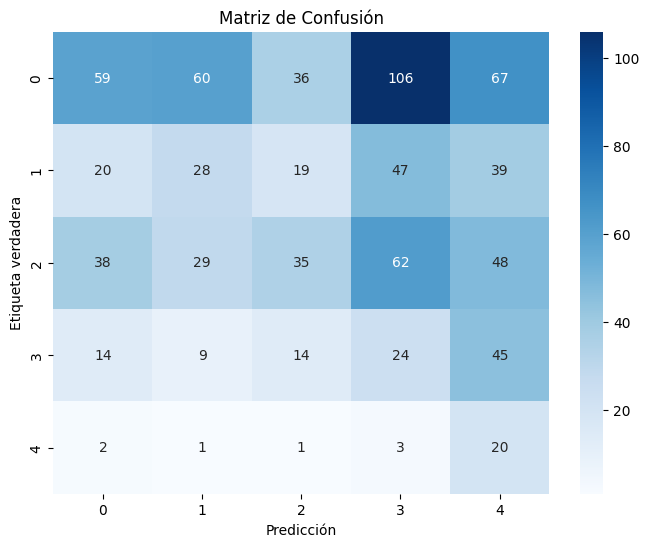

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step
              precision    recall  f1-score   support

           0     0.4436    0.1799    0.2560       328
           1     0.2205    0.1830    0.2000       153
           2     0.3333    0.1651    0.2208       212
           3     0.0992    0.2264    0.1379       106
           4     0.0913    0.7407    0.1626        27

    accuracy                         0.2010       826
   macro avg     0.2376    0.2990    0.1955       826
weighted avg     0.3183    0.2010    0.2184       826



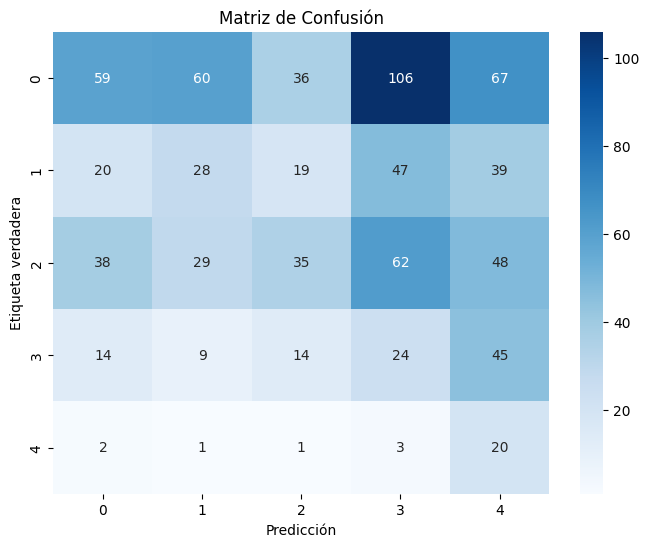

✅ Completado en 184.01s
📈 Acc final: 0.2472 | Val Acc: 0.2010

🔵 MODELO 2/7: EfficientNetB0
📝 Descripción: EfficientNetB0 preentrenado
--------------------------------------------------
⚙️  Creando modelo...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
📊 Parámetros totales: 4,384,936
📊 Parámetros entrenables: 4,339,841
🔥 Entrenando...
[get_datagen] tarea=0, regression=False, augment=True, balanced=True
[get_datagen] Imágenes encontradas: 5778
[get_datagen] Tras tarea: {0: 2286, 2: 1516, 1: 1046, 3: 757, 4: 173}
[get_datagen] Tras balance: {0: 2286, 2: 2286, 1: 2286, 3: 2286, 4: 2286}
Found 11430 validated image filenames belonging to 5 classes.
[get_datagen] Generador creado: mode=categorical, muestras=11430
[get_datagen] tarea=0, regression=False, augment=False, balanced=False
[get_datagen] Imágenes encontradas: 826
[get_datagen] Tras tarea: {0: 328, 2: 212, 1: 153, 3: 106, 4: 27}
Found 826 validated image filenames belonging to 5 classes.
[get_datagen] Generador creado: mode=ca

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.36562, saving model to best_model.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step
              precision    recall  f1-score   support

           0     0.6210    0.4695    0.5347       328
           1     0.1914    0.6405    0.2947       153
           2     0.8000    0.0189    0.0369       212
           3     0.7547    0.3774    0.5031       106
           4     0.7500    0.2222    0.3429        27

    accuracy                         0.3656       826
   macro avg     0.6234    0.3457    0.3425       826
weighted avg     0.6087    0.3656    0.3522       826



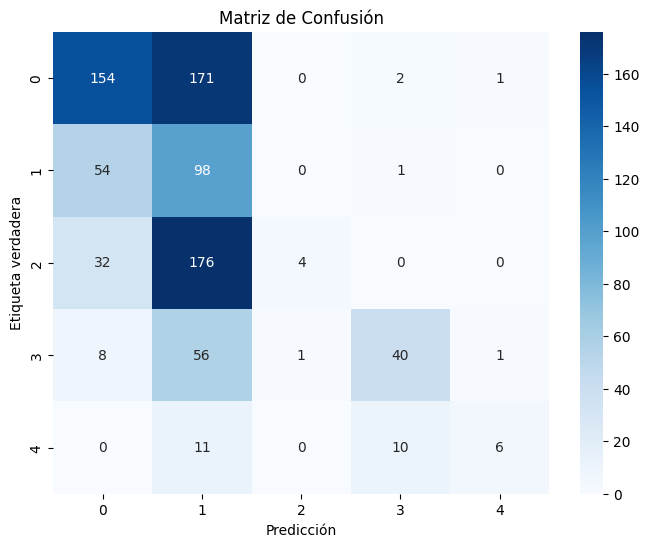

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step
              precision    recall  f1-score   support

           0     0.6210    0.4695    0.5347       328
           1     0.1914    0.6405    0.2947       153
           2     0.8000    0.0189    0.0369       212
           3     0.7547    0.3774    0.5031       106
           4     0.7500    0.2222    0.3429        27

    accuracy                         0.3656       826
   macro avg     0.6234    0.3457    0.3425       826
weighted avg     0.6087    0.3656    0.3522       826



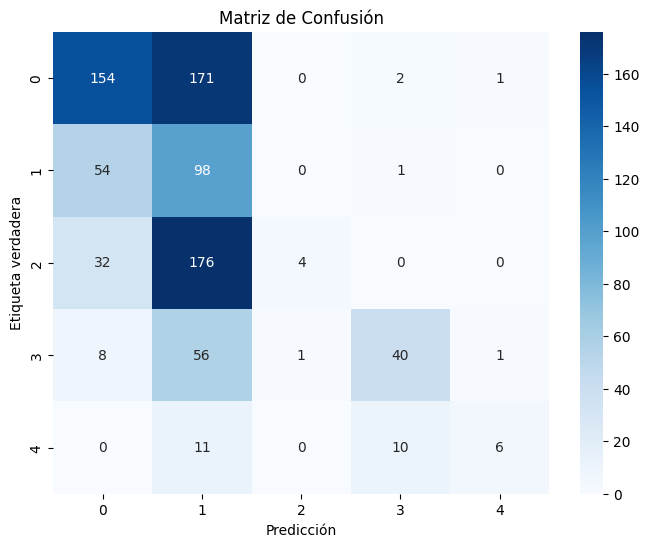

✅ Completado en 263.16s
📈 Acc final: 0.4870 | Val Acc: 0.3656

🤖 MODELO 3/7: Transformer Simple
📝 Descripción: Transformer rápido y eficiente
--------------------------------------------------
⚙️  Creando modelo...


config.json: 0.00B [00:00, ?B/s]

You are using a model of type vit to instantiate a model of type deit. This is not supported for all configurations of models and can yield errors.


tf_model.h5:   0%|          | 0.00/347M [00:00<?, ?B/s]

Some layers from the model checkpoint at facebook/deit-base-patch16-224 were not used when initializing TFDeiTModel: ['classifier', 'vit']
- This IS expected if you are initializing TFDeiTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDeiTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDeiTModel were not initialized from the model checkpoint at facebook/deit-base-patch16-224 and are newly initialized: ['deit']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` arg

📊 Parámetros totales: 199,685
📊 Parámetros entrenables: 199,685
🔥 Entrenando...
[get_datagen] tarea=0, regression=False, augment=True, balanced=True
[get_datagen] Imágenes encontradas: 5778
[get_datagen] Tras tarea: {0: 2286, 2: 1516, 1: 1046, 3: 757, 4: 173}
[get_datagen] Tras balance: {0: 2286, 2: 2286, 1: 2286, 3: 2286, 4: 2286}
Found 11430 validated image filenames belonging to 5 classes.
[get_datagen] Generador creado: mode=categorical, muestras=11430
[get_datagen] tarea=0, regression=False, augment=False, balanced=False
[get_datagen] Imágenes encontradas: 826
[get_datagen] Tras tarea: {0: 328, 2: 212, 1: 153, 3: 106, 4: 27}
Found 826 validated image filenames belonging to 5 classes.
[get_datagen] Generador creado: mode=categorical, muestras=826

🚀 Iniciando entrenamiento para la tarea: 0
------------------------------------------------------------
   • Tipo de tarea     : Clasificación
   • Pesos congelados  : No
   • Fine-tuning activo: No
   • Dataset balanceado: Sí
   • Tamaño

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.03269, saving model to best_model.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 180ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       328
           1     0.0000    0.0000    0.0000       153
           2     0.0000    0.0000    0.0000       212
           3     0.0000    0.0000    0.0000       106
           4     0.0327    1.0000    0.0633        27

    accuracy                         0.0327       826
   macro avg     0.0065    0.2000    0.0127       826
weighted avg     0.0011    0.0327    0.0021       826



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


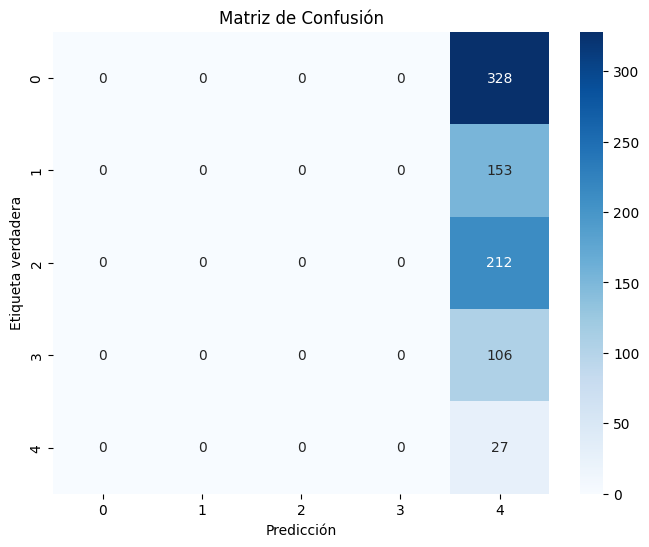

52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       328
           1     0.0000    0.0000    0.0000       153
           2     0.0000    0.0000    0.0000       212
           3     0.0000    0.0000    0.0000       106
           4     0.0327    1.0000    0.0633        27

    accuracy                         0.0327       826
   macro avg     0.0065    0.2000    0.0127       826
weighted avg     0.0011    0.0327    0.0021       826



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


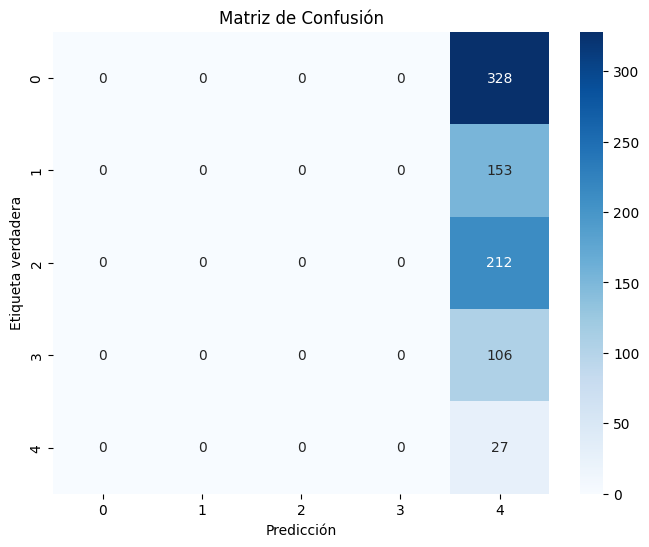

You are using a model of type vit to instantiate a model of type deit. This is not supported for all configurations of models and can yield errors.


✅ Completado en 182.02s
📈 Acc final: 0.2020 | Val Acc: 0.0327

🚀 MODELO 4/7: Transformer Advanced
📝 Descripción: Transformer de alto rendimiento
--------------------------------------------------
⚙️  Creando modelo...


Some layers from the model checkpoint at facebook/deit-base-patch16-224 were not used when initializing TFDeiTModel: ['classifier', 'vit']
- This IS expected if you are initializing TFDeiTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDeiTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDeiTModel were not initialized from the model checkpoint at facebook/deit-base-patch16-224 and are newly initialized: ['deit']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` arg

📊 Parámetros totales: 1,153,797
📊 Parámetros entrenables: 1,153,797
🔥 Entrenando...
[get_datagen] tarea=0, regression=False, augment=True, balanced=True
[get_datagen] Imágenes encontradas: 5778
[get_datagen] Tras tarea: {0: 2286, 2: 1516, 1: 1046, 3: 757, 4: 173}
[get_datagen] Tras balance: {0: 2286, 2: 2286, 1: 2286, 3: 2286, 4: 2286}
Found 11430 validated image filenames belonging to 5 classes.
[get_datagen] Generador creado: mode=categorical, muestras=11430
[get_datagen] tarea=0, regression=False, augment=False, balanced=False
[get_datagen] Imágenes encontradas: 826
[get_datagen] Tras tarea: {0: 328, 2: 212, 1: 153, 3: 106, 4: 27}
Found 826 validated image filenames belonging to 5 classes.
[get_datagen] Generador creado: mode=categorical, muestras=826

🚀 Iniciando entrenamiento para la tarea: 0
------------------------------------------------------------
   • Tipo de tarea     : Clasificación
   • Pesos congelados  : No
   • Fine-tuning activo: No
   • Dataset balanceado: Sí
   • Ta

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.12833, saving model to best_model.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 192ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       328
           1     0.0000    0.0000    0.0000       153
           2     0.0000    0.0000    0.0000       212
           3     0.1283    1.0000    0.2275       106
           4     0.0000    0.0000    0.0000        27

    accuracy                         0.1283       826
   macro avg     0.0257    0.2000    0.0455       826
weighted avg     0.0165    0.1283    0.0292       826



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


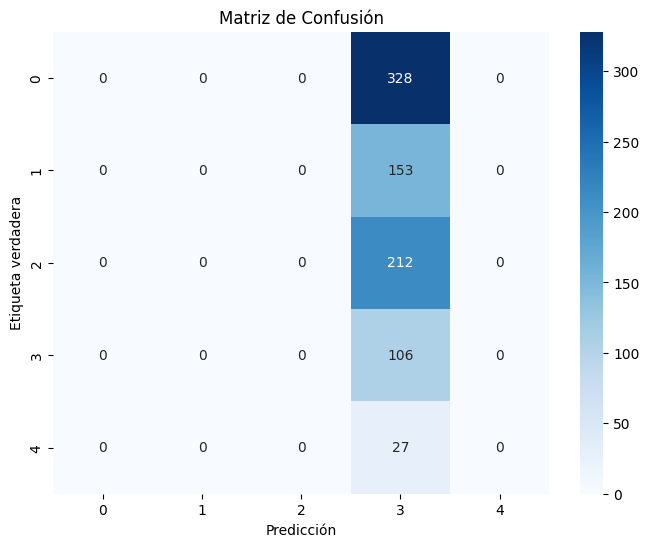

52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       328
           1     0.0000    0.0000    0.0000       153
           2     0.0000    0.0000    0.0000       212
           3     0.1283    1.0000    0.2275       106
           4     0.0000    0.0000    0.0000        27

    accuracy                         0.1283       826
   macro avg     0.0257    0.2000    0.0455       826
weighted avg     0.0165    0.1283    0.0292       826



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


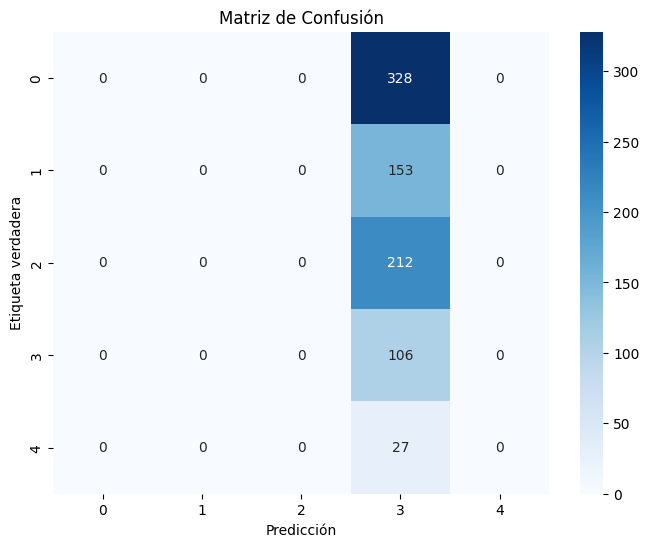

✅ Completado en 186.77s
📈 Acc final: 0.1953 | Val Acc: 0.1283

📊 RESUMEN DE COMPARACIÓN RÁPIDA
                Modelo Parámetros Tiempo (s) Acc Final Val Acc Loss Final Val Loss
            🟠 CNN Deep 25,981,477     184.01    0.2472  0.2010     1.9382   1.7215
      🔵 EfficientNetB0  4,384,936     263.16    0.4870  0.3656     1.3594   1.4748
  🤖 Transformer Simple    199,685     182.02    0.2020  0.0327     1.6497   1.6308
🚀 Transformer Advanced  1,153,797     186.77    0.1953  0.1283     1.6359   1.6287

🏆 RANKING POR PRECISIÓN DE VALIDACIÓN
1. 🔵 EfficientNetB0: 0.3656
   📊 4,384,936 parámetros | ⏱️ 263.16s
2. 🟠 CNN Deep: 0.2010
   📊 25,981,477 parámetros | ⏱️ 184.01s
3. 🚀 Transformer Advanced: 0.1283
   📊 1,153,797 parámetros | ⏱️ 186.77s
4. 🤖 Transformer Simple: 0.0327
   📊 199,685 parámetros | ⏱️ 182.02s

💡 RECOMENDACIONES
🥇 Mejor modelo: 🔵 EfficientNetB0
   📈 Precisión de validación: 0.3656
⚡ Más eficiente: 🔵 EfficientNetB0
   📊 Ratio precisión/tiempo: 0.001389

🔍 Para entrenamien

{'CNN Deep': {'icon': '🟠',
  'description': 'CNN profunda con regularización',
  'total_params': 25981477,
  'trainable_params': 25980069,
  'training_time': 184.0080738067627,
  'final_loss': 1.938242793083191,
  'final_acc': 0.24715660512447357,
  'final_val_loss': 1.7215427160263062,
  'final_val_acc': 0.20096851885318756,
  'success': True},
 'EfficientNetB0': {'icon': '🔵',
  'description': 'EfficientNetB0 preentrenado',
  'total_params': 4384936,
  'trainable_params': 4339841,
  'training_time': 263.15559101104736,
  'final_loss': 1.3594038486480713,
  'final_acc': 0.4869641363620758,
  'final_val_loss': 1.4747973680496216,
  'final_val_acc': 0.36561742424964905,
  'success': True},
 'Transformer Simple': {'icon': '🤖',
  'description': 'Transformer rápido y eficiente',
  'total_params': 199685,
  'trainable_params': 199685,
  'training_time': 182.01772093772888,
  'final_loss': 1.6497018337249756,
  'final_acc': 0.20201225578784943,
  'final_val_loss': 1.6308002471923828,
  'final

In [2]:
def quick_model_comparison():
    """
    Función de prueba rápida para comparar todos los modelos en la tarea 0.
    Entrena cada modelo por 1 época para comparación rápida de rendimiento.
    """
    print("🚀 COMPARACIÓN RÁPIDA DE MODELOS - TAREA 0 (Multiclase KL 0-4)")
    print("=" * 70)
    
    # Configuración común para pruebas rápidas
    tarea = 0  # Multiclase (KL 0-4)
    regression = False
    batch_size = 16  # Batch pequeño para rapidez
    epochs = 1       # Solo 1 época para prueba
    verbose = 1
    
    # Determinar número de clases
    num_classes = get_num_classes(tarea, regression)
    print(f"📊 Configuración: Tarea {tarea}, {num_classes} clases, {epochs} época(s)")
    print(f"📦 Batch size: {batch_size}")
    print("-" * 70)
    
    # Diccionario para almacenar resultados
    results = {}
    
    # Lista de modelos a probar
    models_to_test = [
        {
            'name': 'CNN Deep',
            'icon': '🟠',
            'model_fn': lambda: cnn_deep(num_classes=num_classes, regression=regression),
            'description': 'CNN profunda con regularización'
        },
        
        # Modelos preentrenados
        {
            'name': 'EfficientNetB0',
            'icon': '🔵',
            'model_fn': lambda: efficientnet_model(num_classes=num_classes, regression=regression, frozen=False),
            'description': 'EfficientNetB0 preentrenado'
        },
        
        # Transformers
        {
            'name': 'Transformer Simple',
            'icon': '🤖',
            'model_fn': lambda: transformer_simple(num_classes=num_classes, regression=regression, frozen=False, pretrained=True),
            'description': 'Transformer rápido y eficiente'
        },
        {
            'name': 'Transformer Advanced',
            'icon': '🚀',
            'model_fn': lambda: transformer_advanced(num_classes=num_classes, regression=regression, frozen=False, pretrained=True),
            'description': 'Transformer de alto rendimiento'
        }
    ]
    
    # Probar cada modelo
    for i, model_config in enumerate(models_to_test, 1):
        print(f"\n{model_config['icon']} MODELO {i}/7: {model_config['name']}")
        print(f"📝 Descripción: {model_config['description']}")
        print("-" * 50)
        
        try:
            # Crear modelo
            print("⚙️  Creando modelo...")
            model = model_config['model_fn']()
            
            # Contar parámetros
            total_params = model.count_params()
            trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
            
            print(f"📊 Parámetros totales: {total_params:,}")
            print(f"📊 Parámetros entrenables: {trainable_params:,}")
            
            # Entrenar modelo
            print("🔥 Entrenando...")
            start_time = tf.timestamp()
            
            model_trained, history = train_model(
                model=model,
                tarea=tarea,
                regression=regression,
                frozen=False,
                finetuning=False,
                balanced=True,
                batch_size=batch_size,
                epochs=epochs,
                verbose=0  # Silencioso para comparación
            )
            
            end_time = tf.timestamp()
            training_time = float(end_time - start_time)
            
            # Obtener métricas finales
            final_loss = history.history['loss'][-1]
            final_acc = history.history['accuracy'][-1]
            final_val_loss = history.history['val_loss'][-1]
            final_val_acc = history.history['val_accuracy'][-1]
            
            # Guardar resultados
            results[model_config['name']] = {
                'icon': model_config['icon'],
                'description': model_config['description'],
                'total_params': total_params,
                'trainable_params': trainable_params,
                'training_time': training_time,
                'final_loss': final_loss,
                'final_acc': final_acc,
                'final_val_loss': final_val_loss,
                'final_val_acc': final_val_acc,
                'success': True
            }
            
            print(f"✅ Completado en {training_time:.2f}s")
            print(f"📈 Acc final: {final_acc:.4f} | Val Acc: {final_val_acc:.4f}")
            
        except Exception as e:
            print(f"❌ Error: {str(e)}")
            results[model_config['name']] = {
                'icon': model_config['icon'],
                'description': model_config['description'],
                'error': str(e),
                'success': False
            }
    
    # ========================================================================
    # MOSTRAR RESUMEN DE RESULTADOS
    # ========================================================================
    print("\n" + "=" * 70)
    print("📊 RESUMEN DE COMPARACIÓN RÁPIDA")
    print("=" * 70)
    
    # Crear DataFrame para mejor visualización
    summary_data = []
    for name, result in results.items():
        if result['success']:
            summary_data.append({
                'Modelo': f"{result['icon']} {name}",
                'Parámetros': f"{result['total_params']:,}",
                'Tiempo (s)': f"{result['training_time']:.2f}",
                'Acc Final': f"{result['final_acc']:.4f}",
                'Val Acc': f"{result['final_val_acc']:.4f}",
                'Loss Final': f"{result['final_loss']:.4f}",
                'Val Loss': f"{result['final_val_loss']:.4f}"
            })
        else:
            summary_data.append({
                'Modelo': f"{result['icon']} {name}",
                'Parámetros': 'ERROR',
                'Tiempo (s)': 'ERROR',
                'Acc Final': 'ERROR',
                'Val Acc': 'ERROR',
                'Loss Final': 'ERROR',
                'Val Loss': 'ERROR'
            })
    
    # Mostrar tabla
    if summary_data:
        df_summary = pd.DataFrame(summary_data)
        print(df_summary.to_string(index=False))
    
    # ========================================================================
    # RANKING POR PRECISIÓN
    # ========================================================================
    print("\n" + "=" * 70)
    print("🏆 RANKING POR PRECISIÓN DE VALIDACIÓN")
    print("=" * 70)
    
    # Filtrar solo modelos exitosos y ordenar por val_acc
    successful_models = [(name, result) for name, result in results.items() if result['success']]
    successful_models.sort(key=lambda x: x[1]['final_val_acc'], reverse=True)
    
    for i, (name, result) in enumerate(successful_models, 1):
        print(f"{i}. {result['icon']} {name}: {result['final_val_acc']:.4f}")
        print(f"   📊 {result['total_params']:,} parámetros | ⏱️ {result['training_time']:.2f}s")
    
    # ========================================================================
    # RECOMENDACIONES
    # ========================================================================
    print("\n" + "=" * 70)
    print("💡 RECOMENDACIONES")
    print("=" * 70)
    
    if successful_models:
        best_model = successful_models[0]
        print(f"🥇 Mejor modelo: {best_model[1]['icon']} {best_model[0]}")
        print(f"   📈 Precisión de validación: {best_model[1]['final_val_acc']:.4f}")
        
        # Encontrar modelo más eficiente (mejor ratio precisión/tiempo)
        efficiency_scores = []
        for name, result in successful_models:
            if result['training_time'] > 0:
                efficiency = result['final_val_acc'] / result['training_time']
                efficiency_scores.append((name, result, efficiency))
        
        if efficiency_scores:
            efficiency_scores.sort(key=lambda x: x[2], reverse=True)
            most_efficient = efficiency_scores[0]
            print(f"⚡ Más eficiente: {most_efficient[1]['icon']} {most_efficient[0]}")
            print(f"   📊 Ratio precisión/tiempo: {most_efficient[2]:.6f}")
    
    print("\n🔍 Para entrenamientos completos, usa las funciones main() o train_model()")
    print("💾 Esta fue solo una comparación rápida con 1 época")
    
    return results

quick_model_comparison()

In [ ]:
"""
📊 RESUMEN DE COMPARACIÓN RÁPIDA
======================================================================
                Modelo Parámetros Tiempo (s) Acc Final Val Acc Loss Final Val Loss
            🟠 CNN Deep 25,981,477     184.01    0.2472  0.2010     1.9382   1.7215
      🔵 EfficientNetB0  4,384,936     263.16    0.4870  0.3656     1.3594   1.4748
  🤖 Transformer Simple    199,685     182.02    0.2020  0.0327     1.6497   1.6308
🚀 Transformer Advanced  1,153,797     186.77    0.1953  0.1283     1.6359   1.6287

======================================================================
🏆 RANKING POR PRECISIÓN DE VALIDACIÓN
======================================================================
1. 🔵 EfficientNetB0: 0.3656
   📊 4,384,936 parámetros | ⏱️ 263.16s
2. 🟠 CNN Deep: 0.2010
   📊 25,981,477 parámetros | ⏱️ 184.01s
3. 🚀 Transformer Advanced: 0.1283
   📊 1,153,797 parámetros | ⏱️ 186.77s
4. 🤖 Transformer Simple: 0.0327
   📊 199,685 parámetros | ⏱️ 182.02s
"""